In [2]:
!git clone https://github.com/VijayaRajasree/Brain-tumor-detection-system.git
%cd Brain-tumor-detection-system

Cloning into 'Brain-tumor-detection-system'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), done.
/content/Brain-tumor-detection-system


In [3]:
!ls /content

Brain-tumor-detection-system  sample_data


In [5]:
!cp "/content/Brain_tumor_detection (2).ipynb" "/content/Brain-tumor-detection-system/"


cp: cannot stat '/content/Brain_tumor_detection (2).ipynb': No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Imports Libraries and Tools


In [ ]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

Load Datasets


In [ ]:
train_dir = '/content/drive/MyDrive/MRI Images/Training'
test_dir = '/content/drive/MyDrive/MRI Images/Testing'

#load and shuffle the train data
train_paths = [] #stores full path
train_labels = [] #stores label


for label in os.listdir(train_dir): #lists all subfolders
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

#shuffling ensures that the order of data does not have bias
train_paths, train_labels = shuffle(train_paths, train_labels)
train_paths

#load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)
test_paths

['/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0273.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0118.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0260.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0180.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0255.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0202.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0295.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0307.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0061.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0028.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0280.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0107.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0183.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0063.jpg',
 '/content/drive/MyDri

Data Visualization

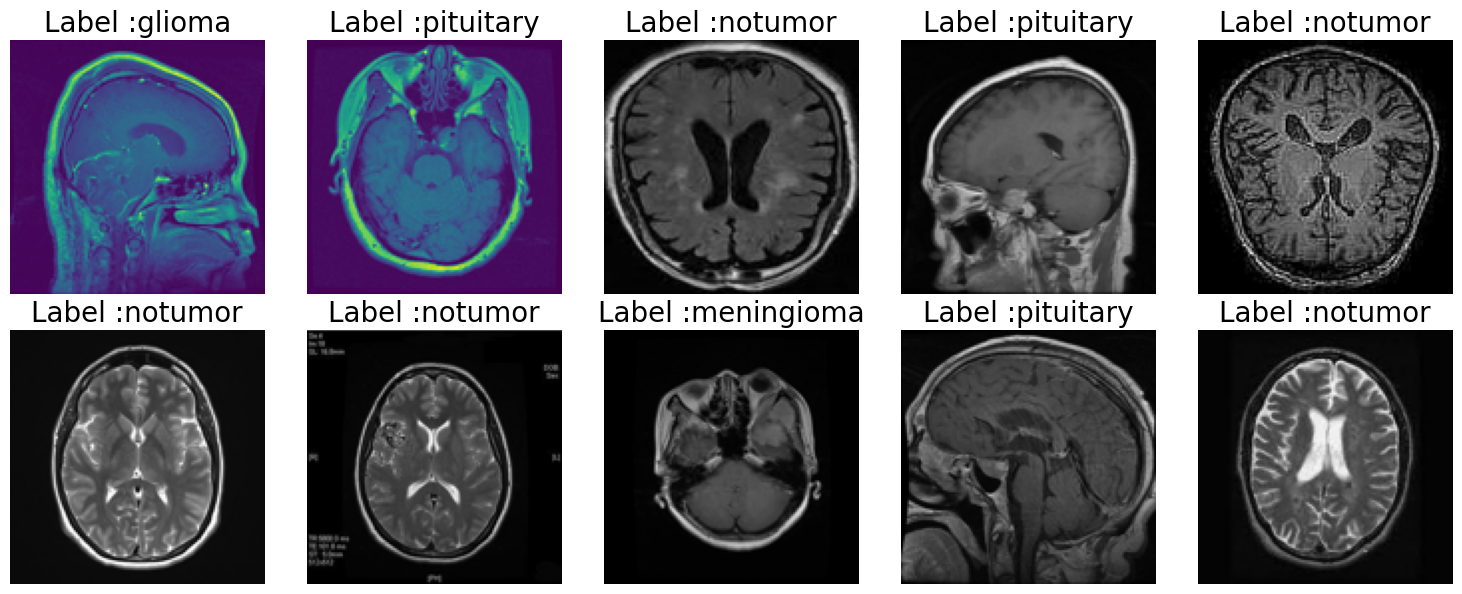

In [ ]:
import random
import matplotlib.pyplot as plt

#select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

#create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

#loop through random indices and display images
for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128, 128))

  #display images
  axes[i].imshow(img) #displays image
  axes[i].axis('off') #hides borders
  axes[i].set_title(f"Label :{train_labels[idx]}", fontsize=20)

plt.tight_layout()
plt.show()

Image PreProcessing

In [ ]:
# 1.Image Augmentation Function

def augment_image(image):
    """Applies random augmentations to an image."""
    # Convert to PIL image if it's not already
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)

    # Random rotations
    angle = random.randint(-10, 10)
    image = image.rotate(angle)

    # Random flips
    if random.random() > 0.5:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() > 0.5:
        image = image.transpose(Image.FLIP_TOP_BOTTOM)

    # Random brightness and contrast adjustments
    enhancer = ImageEnhance.Brightness(image)
    image = enhancer.enhance(random.uniform(0.8, 1.2))
    enhancer = ImageEnhance.Contrast(image)
    image = enhancer.enhance(random.uniform(0.8, 1.2))

    return np.array(image)


#2. Load images and apply augmentation

def open_images(paths, augment=False):
    """Loads images from given paths and optionally applies augmentation."""
    images = []
    for path in paths:
        try:
            img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
            img = np.array(img)
            if augment:
                img = augment_image(img)
            images.append(img)
        except Exception as e:
            print(f"Error loading image {path}: {e}")
            # Append a placeholder or handle the error as needed
            images.append(None) # Or np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)


    # Filter out None values if any image failed to load

    images = [img for img in images if img is not None]
    return np.array(images)


#3. Encoder labels (Convert label names to integers)

def encode_label(labels):
    """Encodes labels to integers."""
    unique_labels = sorted(list(set(labels)))
    label_map = {label: i for i, label in enumerate(unique_labels)}
    encoded = [label_map[label] for label in labels]
    return np.array(encoded, dtype=np.int64)


#4. Data generator for batching

def datagen(paths, labels, batch_size=12, epochs=1):
    """Generates batches of augmented image data and encoded labels."""
    num_samples = len(paths)
    encoded_labels = encode_label(labels)

    for epoch in range(epochs):
        # Shuffle data at the beginning of each epoch
        paths, encoded_labels = shuffle(paths, encoded_labels)

        for offset in range(0, num_samples, batch_size):
            batch_paths = paths[offset:offset + batch_size]
            batch_labels = encoded_labels[offset:offset + batch_size]

            # Load and augment images
            batch_images = open_images(batch_paths, augment=True)

            # Ensure batch_images is not empty and labels match images length
            if len(batch_images) > 0 and len(batch_images) == len(batch_labels):
                 yield batch_images, batch_labels

In [ ]:
IMAGE_SIZE = 128 # Define the image size

In [ ]:
# Pick a small subset of your training data for testing
sample_paths = train_paths[:5] #only first 5 images
sample_labels = train_labels[:5]

# Generate one batch from the datagen
generator = datagen(sample_paths, sample_labels, batch_size=5, epochs=1)
batch_images, batch_labels = next(generator) #gives the next batch of images and labels from the generator

print("Batch Images Shape:", batch_images.shape)
print("Batch Labels Shape:", batch_labels.shape)

Batch Images Shape: (5, 128, 128, 3)
Batch Labels Shape: (5,)


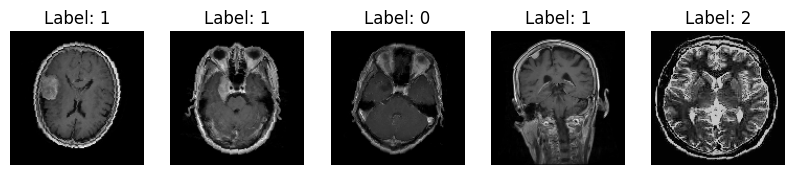

In [ ]:
import matplotlib.pyplot as plt

# Show the augmented images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1) # 1 row and 5 cols, and select the (i+1)th position for the next image
    plt.imshow(batch_images[i].astype('uint8')) #converts pixel values to the standard 0-255 integer format
    plt.title(f"Label: {batch_labels[i]}")
    plt.axis('off')
plt.show()


In [ ]:
# ------------------------------------------
# Brain Tumor Detection - VGG16 with Early Stopping
# ------------------------------------------

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ------------------------
# 1. Parameters
# ------------------------
IMAGE_SIZE = 128
BATCH_SIZE = 20
EPOCHS = 5  # Allow up to 5 epochs (EarlyStopping will stop earlier if accuracy stops improving)

# ------------------------
# 2. Data Augmentation
# ------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # 80-20 split
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation'
)

# ------------------------
# 3. Base Model - VGG16
# ------------------------
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
                   include_top=False,
                   weights='imagenet')

# Unfreeze last 10 layers for fine-tuning
for layer in base_model.layers[:-10]:
    layer.trainable = False
for layer in base_model.layers[-10:]:
    layer.trainable = True

# ------------------------
# 4. Build Model
# ------------------------
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    Flatten(),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(4, activation='softmax')  # 4 tumor classes
])

# ------------------------
# 5. Compile Model
# ------------------------
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

# ------------------------
# 6. Early Stopping Callback
# ------------------------
early_stop = EarlyStopping(
    monitor='val_sparse_categorical_accuracy',  # monitor validation accuracy
    patience=2,                                # stop if no improvement for 2 epochs
    restore_best_weights=True,                 # restore best weights
    mode='max',
    verbose=1
)

# ------------------------
# 7. Train Model
# ------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 2370s 10s/step - loss: 0.9260 - sparse_categorical_accuracy: 0.6566 - val_loss: 1.8380 - val_sparse_categorical_accuracy: 0.5285
Epoch 2/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 2398s 10s/step - loss: 0.3880 - sparse_categorical_accuracy: 0.8632 - val_loss: 0.6375 - val_sparse_categorical_accuracy: 0.7748
Epoch 3/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 2388s 10s/step - loss: 0.2709 - sparse_categorical_accuracy: 0.9017 - val_loss: 0.4723 - val_sparse_categorical_accuracy: 0.8230
Epoch 4/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 2415s 10s/step - loss: 0.2476 - sparse_categorical_accuracy: 0.9035 - val_loss: 1.3542 - val_sparse_categorical_accuracy: 0.6284
Epoch 5/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 2389s 10s/step - loss: 0.2405 - sparse_categorical_accuracy: 0.9116 - val_loss: 1.5499 - val_sparse_categorical_accuracy: 0.6161
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


Train and Val Plots

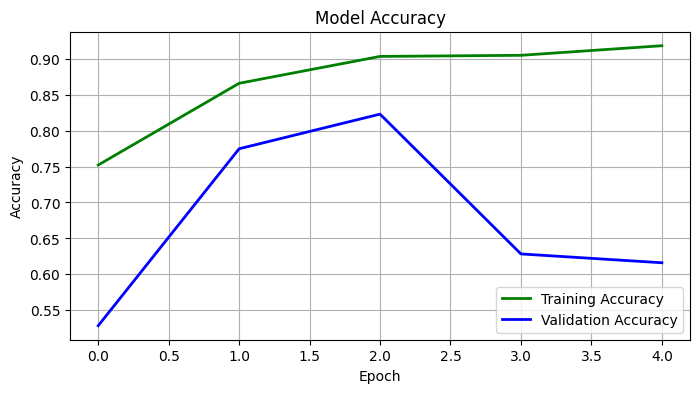

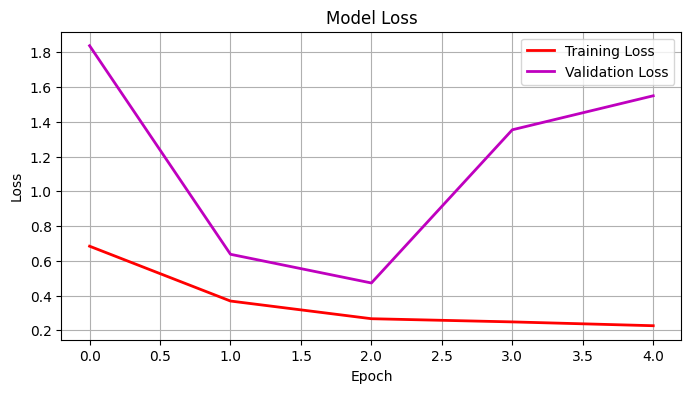

58/58 ━━━━━━━━━━━━━━━━━━━━ 262s 5s/step - loss: 0.5541 - sparse_categorical_accuracy: 0.8030

✅ Final Validation Accuracy: 81.24%


In [ ]:
# ------------------------
# 8. Plot Accuracy (Train vs Val)
# ------------------------
plt.figure(figsize=(8,4))
plt.plot(history.history['sparse_categorical_accuracy'], 'g-', linewidth=2)
plt.plot(history.history['val_sparse_categorical_accuracy'], 'b-', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'], loc='lower right')
plt.grid(True)
plt.show()

# ------------------------
# 9. Plot Loss (Train vs Val)
# ------------------------
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], 'r-', linewidth=2)
plt.plot(history.history['val_loss'], 'm-', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'], loc='upper right')
plt.grid(True)
plt.show()

# ------------------------
# 10. Evaluate on Validation Set
# ------------------------
val_loss, val_acc = model.evaluate(val_generator)
print(f"\n✅ Final Validation Accuracy: {val_acc*100:.2f}%")


Model Classification Report

58/58 ━━━━━━━━━━━━━━━━━━━━ 256s 4s/step
📊 Classification Report:

              precision    recall  f1-score   support

      glioma       0.24      0.23      0.24       264
  meningioma       0.22      0.32      0.26       267
     notumor       0.27      0.22      0.24       319
   pituitary       0.24      0.19      0.21       291

    accuracy                           0.24      1141
   macro avg       0.24      0.24      0.24      1141
weighted avg       0.24      0.24      0.24      1141



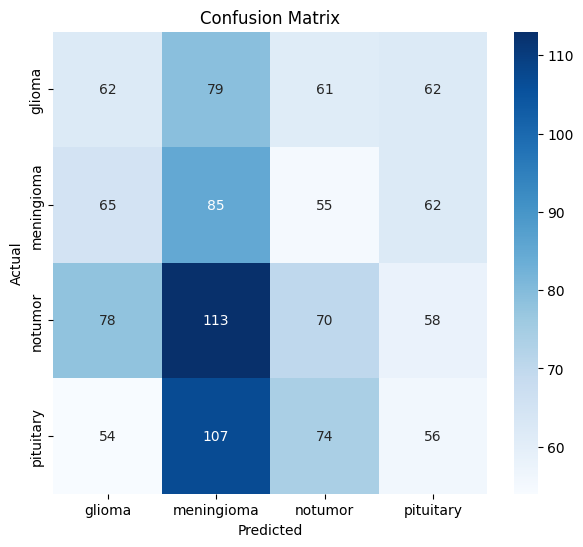

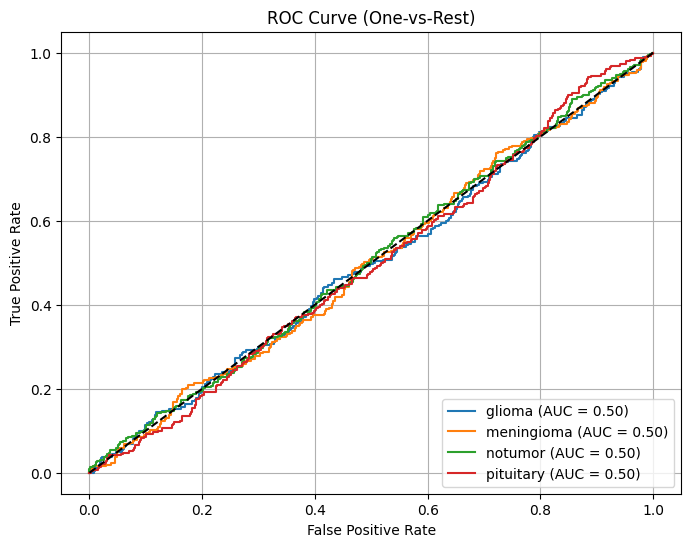

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------------
# 1. Get true labels and predictions
# -------------------------------

# Reset the generator before prediction (important!)
val_generator.reset()

# Predict on validation data
pred_probs = model.predict(val_generator)
pred_classes = np.argmax(pred_probs, axis=1)

# True labels
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())  # ['glioma', 'meningioma', 'notumor', 'pituitary']

# -------------------------------
# 2. Classification Report
# -------------------------------
print("📊 Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# -------------------------------
# 3. Confusion Matrix
# -------------------------------
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# -------------------------------
# 4. ROC Curve (for multi-class)
# -------------------------------
from sklearn.preprocessing import label_binarize

# Binarize the labels for ROC calculation
true_binarized = label_binarize(true_classes, classes=range(len(class_labels)))
n_classes = true_binarized.shape[1]

# Compute ROC curve and AUC for each class
plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(true_binarized[:, i], pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# Task
Upload the `Brain_tumor_detection (2).ipynb` notebook from your Google Drive to the `Brain-tumor-detection-system` GitHub repository.

## Verify File Existence and Location

### Subtask:
First, ensure the file you wish to upload is present in your Colab environment. If it's the `Brain_tumor_detection (2).ipynb` file that previously caused an error, make sure it is in `/content/` or specify its correct path. This step will verify the file's current location.


**Reasoning**:
To locate the `Brain_tumor_detection (2).ipynb` file, I will list the contents of the `/content/drive/MyDrive/` directory, as instructed, since the file is likely there.



In [6]:
!ls -R /content/drive/MyDrive/

ls: cannot access '/content/drive/MyDrive/': No such file or directory


**Reasoning**:
The previous command to list contents of `/content/drive/MyDrive/` failed because the directory was not found, despite Google Drive being mounted. To diagnose this, I will list the contents of `/content/drive/` to see what subdirectories are present after mounting, which might reveal a different mount point name or a mounting issue.



In [7]:
print('Listing contents of /content/drive/')
!ls -R /content/drive/

Listing contents of /content/drive/
ls: cannot access '/content/drive/': No such file or directory


**Reasoning**:
Despite the previous output indicating Google Drive was mounted, subsequent attempts to list its contents failed. This suggests a potential issue with the mount point or its accessibility. To ensure the drive is correctly mounted and accessible, I will explicitly remount it using `force_remount=True` as suggested in the prior mount message. After successful remounting, I will re-attempt to list the contents of `/content/drive/MyDrive/` to find the target file.



In [8]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Remounting successful. Listing contents of /content/drive/MyDrive/ to locate the notebook.')
!ls -R /content/drive/MyDrive/

MessageError: Error: credential propagation was unsuccessful